<center> <h2><b>4 Foundation Models</b></h2> </center>

#### Q4.1 Prompting an LLM to solve a time-series problem

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import importlib
import sys
sys.path.append("..")  # Ensure the parent directory is in the path

from data_parsing.data_parsing import parse_data, extract_labels
import visualization.data_exploration_plots
import data_preprocessing.data_preprocessing
import models.classic_ml.classic_ml_models

# Reload the module to reflect changes
importlib.reload(visualization.data_exploration_plots)
importlib.reload(data_preprocessing.data_preprocessing)
importlib.reload(models.classic_ml.classic_ml_models)

from visualization.data_exploration_plots import *
from data_preprocessing.data_cleaning import *
from data_preprocessing.data_preprocessing import *
from models.classic_ml.classic_ml_models import *
import pickle

In [2]:
# Read the parsed data saved as parquet files
X_set_a, X_set_b, X_set_c = pd.read_parquet('set-a.parquet'), pd.read_parquet('set-b.parquet'), pd.read_parquet('set-c.parquet')
Y_set_a, Y_set_b, Y_set_c = pd.read_parquet('outcomes-a.parquet'), pd.read_parquet('outcomes-b.parquet'), pd.read_parquet('outcomes-c.parquet')

# From X_set_c drop unnamed parameter column
X_set_c = X_set_c.drop(columns='')

In [3]:
X_set_a = clean_data(X_set_a)
X_set_b = clean_data(X_set_b)
X_set_c = clean_data(X_set_c)

X_train = X_set_a.sort_values(by=['recordid', 'time'])
X_valid = X_set_b.sort_values(by=['recordid', 'time'])
X_test = X_set_c.sort_values(by=['recordid', 'time'])

y_train = np.array(Y_set_a.drop(columns=['recordid'])).ravel()
y_valid = np.array(Y_set_b.drop(columns=['recordid'])).ravel()
y_test = np.array(Y_set_c.drop(columns=['recordid'])).ravel()

In [4]:
X_train, X_valid, X_test = prepare_data_advanced_for_ML_classifier(X_train, X_valid, X_test)

In [5]:
X_train

,DiasABP_first,DiasABP_last,DiasABP_lowest,DiasABP_highest,DiasABP_median,GCS_first,GCS_last,GCS_lowest,GCS_highest,GCS_median,...,WBC_first,WBC_last,Weight_first,Weight_last,Urine_first,Urine_last,Age,Gender,Height,MechVent
0,0.0,0.000000,0.529412,-0.458333,0.000000,0.0,0.0,0.636364,0.0,0.2,...,0.0,-0.311475,0.000000,0.000000,0.0,1.428571,-0.514851,-1.0,0.0,0.0
1,0.0,-0.888889,-0.235294,0.208333,0.000000,0.0,0.0,-0.363636,0.0,0.2,...,0.0,0.327869,-0.170104,0.063745,0.0,1.000000,0.356436,0.0,5.1,0.0
2,0.0,1.222222,0.117647,0.458333,0.000000,0.0,-2.0,-0.181818,-1.0,-1.8,...,0.0,-0.836066,-0.990857,-0.928287,0.0,-0.321429,-0.910891,-1.0,0.0,0.0
3,0.0,0.000000,0.529412,-0.458333,0.000000,0.0,0.0,0.636364,0.0,0.2,...,0.0,-0.557377,0.195620,0.183267,0.0,3.357143,0.039604,0.0,10.1,0.0
4,0.0,0.000000,0.529412,-0.458333,0.000000,0.0,0.0,0.636364,0.0,0.2,...,0.0,-1.065574,0.000000,0.000000,0.0,0.000000,0.831683,-1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,0.0,2.222222,-0.294118,0.500000,3.000000,0.0,0.0,-0.363636,0.0,0.0,...,0.0,1.016393,0.297682,0.278884,0.0,-0.285714,0.118812,-1.0,0.0,0.0
3996,0.0,0.000000,0.529412,-0.458333,0.000000,0.0,0.0,0.636364,0.0,0.2,...,0.0,-1.360656,3.674250,3.442231,0.0,5.857143,-1.663366,0.0,0.0,0.0
3997,0.0,0.666667,0.529412,0.750000,0.000000,0.0,-2.0,-0.363636,-1.0,-1.4,...,0.0,-0.114754,1.233255,1.155378,0.0,-0.428571,-0.910891,0.0,0.0,0.0
3998,0.0,2.555556,0.529412,1.791667,12.000000,0.0,-2.4,-0.363636,-1.0,-1.6,...,0.0,0.032787,0.314693,0.294821,0.0,-0.550000,-1.188119,0.0,0.0,0.0


In [6]:
def transform_to_text(data, columns, y, selected_columns=None):
    """
    Transforms each patient's time series data into a simple aggregated piece of text.

    Parameters:
    - data: pandas DataFrame containing the time series data for patients.
    - columns: List of column names to include in the text.
    - y: Target variable for correlation computation (used only for selecting columns).
    - selected_columns: List of pre-selected columns to use for text generation.

    Returns:
    - List of strings, where each string is the aggregated text for a patient.
    - List of selected columns (if not provided).
    """
    if selected_columns is None:
        # Convert non-numeric columns to NaN and ensure numeric data
        data_numeric = data[columns].apply(pd.to_numeric, errors='coerce')

        # Filter out zero-variance columns before computing correlation
        non_zero_variance_data = data_numeric.loc[:, data_numeric.std() > 0]

        correlations = non_zero_variance_data.corrwith(pd.Series(y, index=data.index), method='pearson')
        correlations = correlations.fillna(0)  # Replace NaNs with 0 to avoid missing correlations

        # Select top correlated features
        selected_columns = correlations.abs().sort_values(ascending=False).head(20).index.tolist()

    sentences = []
    for _, row in data.iterrows():
        patient_text = ["Will the given patient with the following data be discharged alive in the ICU?"]
        for col in selected_columns:
            value = row[col]
            if pd.isna(value):  # Check if the value is NaN
                continue
            sentence = f"{col.replace('_', ' ').capitalize()} {value},"
            patient_text.append(sentence)
        sentences.append(" ".join(patient_text))
    return sentences, selected_columns

# Select columns using train data
train_samples, selected_columns = transform_to_text(X_train, X_train.columns, y_train)
print("Selected columns:", selected_columns)

# Use the same columns for test data
patient_texts, _ = transform_to_text(X_test, X_test.columns, y_test, selected_columns=selected_columns)

# Ensure train_samples_with_answers includes both 0 and 1 outputs
train_samples_with_answers = []
zero_count, one_count = 0, 0

for sample, truth in zip(train_samples, y_train):
    if zero_count < 3 and truth == 0:
        train_samples_with_answers.append(f"{sample} Answer: {truth}")
        zero_count += 1
    elif one_count < 2 and truth == 1:
        train_samples_with_answers.append(f"{sample} Answer: {truth}")
        one_count += 1
    if zero_count >= 3 and one_count >= 2:
        break

patient_texts[0]

Selected columns: ['GCS_last', 'GCS_median', 'BUN_last', 'GCS_highest', 'Lactate_last', 'Bilirubin_last', 'HCO3_last', 'Age', 'Albumin_last', 'Creatinine_last', 'Temp_lowest', 'AST_last', 'Glucose_highest', 'WBC_last', 'ALP_last', 'Urine_last', 'RespRate_lowest', 'Glucose_last', 'HR_highest', 'NISysABP_lowest']


'Will the given patient with the following data be discharged alive in the ICU? Gcs last -1.0, Gcs median -0.8, Bun last 1.1578947368421053, Gcs highest -1.0, Lactate last -5.000000000000001, Bilirubin last -0.39999999999999997, Hco3 last -1.0, Age 0.15841584158415842, Albumin last -1.3, Creatinine last 4.714285714285715, Temp lowest 0.37500000000001, Ast last -30.0, Glucose highest -0.359375, Wbc last -0.49180327868852464, Alp last -32.0, Urine last -0.3357142857142857, Resprate lowest 0.0, Glucose last -0.975, Hr highest -0.8035714285714286, Nisysabp lowest 0.6428571428571429,'

In [7]:
from ollama import chat
from sklearn.metrics import roc_auc_score, average_precision_score
from tqdm import tqdm

# Calculate AUROC and AUPRC without training prompt
responses_no_prompt = []
for text in tqdm(patient_texts, total=len(patient_texts), desc="Processing samples without training prompt"):
    full_prompt = "\nHere is a sample that you need to score on a scale from 1 to 10, where 1 indicates the patient was discharged alive, and 10 signifies an in-hospital death. The only output should be the number, no other text. Always provide a value, even if there are very few features available. Never return 'N/A':\n" + text
    
    stream = chat(
        model='gemma2:2b',
        messages=[{'role': 'user', 'content': full_prompt}],
        stream=True,
    )
    
    response = ""
    for chunk in stream:
        response += chunk['message']['content']
    
    responses_no_prompt.append(response.strip())

# Normalize predicted scores to range [0, 1]
predicted_scores_no_train = [float(resp) / 10.0 for resp in responses_no_prompt]
print("10 first predicted scores without training prompt:", predicted_scores_no_train[:10])

# Calculate AUROC and AUPRC
auroc_no_prompt = roc_auc_score(y_test, predicted_scores_no_train)
auprc_no_prompt = average_precision_score(y_test, predicted_scores_no_train)

print(f"AUROC without training samples: {auroc_no_prompt}")
print(f"AUPRC without training samples: {auprc_no_prompt}")

Processing samples without training prompt: 100%|██████████| 4000/4000 [15:51<00:00,  4.20it/s]

10 first predicted scores without training prompt: [0.2, 0.3, 0.3, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.1]
AUROC without training samples: 0.5338659258424998
AUPRC without training samples: 0.1569903182909451


In [8]:
from ollama import chat
from sklearn.metrics import roc_auc_score, average_precision_score
from tqdm import tqdm

responses = []

train_prompt = "Here are some train samples with answers:\n\n"
train_prompt += "\n\n".join(train_samples_with_answers) + "\n\n"

# Calculate AUROC and AUPRC with training prompt
for text in tqdm(patient_texts, total=len(patient_texts), desc="Processing samples"):
    # To guarantee the model still has access to the training samples if the context window is surpassed, 
    # we provide the training samples for every query
    full_prompt = train_prompt + "Here is a test sample that you need to score on a scale from 1 to 10, where 1 indicates the patient was discharged alive, and 10 signifies an in-hospital death. The only output should be the number, no other text. Always provide a value, even if there are very few features available. Never return 'N/A':\n" + text
    
    stream = chat(
        model='gemma2:2b',
        messages=[{'role': 'user', 'content': full_prompt}],
        stream=True,
    )
    
    response = ""
    for chunk in stream:
        response += chunk['message']['content']
    
    responses.append(response.strip())

# Normalize predicted scores to range [0, 1]
predicted_scores = [float(resp) / 10.0 for resp in responses]
print("10 first predicted scores:", predicted_scores[:10])

# Calculate AUROC and AUPRC
auroc = roc_auc_score(y_test, predicted_scores)
auprc = average_precision_score(y_test, predicted_scores)

print(f"AUROC with training samples: {auroc}")
print(f"AUPRC with training samples: {auprc}")

Processing samples: 100%|██████████| 4000/4000 [18:20<00:00,  3.64it/s]

10 first predicted scores: [0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1]
AUROC with training samples: 0.5024266997034201
AUPRC with training samples: 0.14757201818991114


#### Q4.2 Using LLMs to retrieve embeddings

In [9]:
from ollama import embed
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Retrieve embeddings for training set
train_embeddings = []
for text in tqdm(train_samples, total=len(train_samples), desc="Processing train embeddings"):
    embedding = embed(
        model='gemma2:2b',
        input=text
    )
    train_embeddings.append(embedding.embeddings[0])

train_embeddings_array = np.array(train_embeddings)
print("Train embeddings shape:", train_embeddings_array.shape)

# Retrieve embeddings for testing set
embeddings = []
for text in tqdm(patient_texts, total=len(patient_texts), desc="Processing test embeddings"):
    embedding = embed(
        model='gemma2:2b',
        input=text
    )
    embeddings.append(embedding.embeddings[0])

embeddings_array = np.array(embeddings)
print("Test embeddings shape:", embeddings_array.shape)

clf = LogisticRegression(max_iter=1000)
clf.fit(train_embeddings_array, y_train)

test_predictions = clf.predict(embeddings_array)

test_accuracy = accuracy_score(y_test, test_predictions)
print(f"Test Set Accuracy: {test_accuracy}")

auroc = roc_auc_score(y_test, test_predictions)
auprc = average_precision_score(y_test, test_predictions)

print(f"AUROC: {auroc}")
print(f"AUPRC: {auprc}")

Processing train embeddings: 100%|██████████| 4000/4000 [12:10<00:00,  5.48it/s]


Train embeddings shape: (4000, 2304)


Processing test embeddings: 100%|██████████| 4000/4000 [12:04<00:00,  5.52it/s]


Test embeddings shape: (4000, 2304)
Test Set Accuracy: 0.85375
AUROC: 0.5
AUPRC: 0.14625


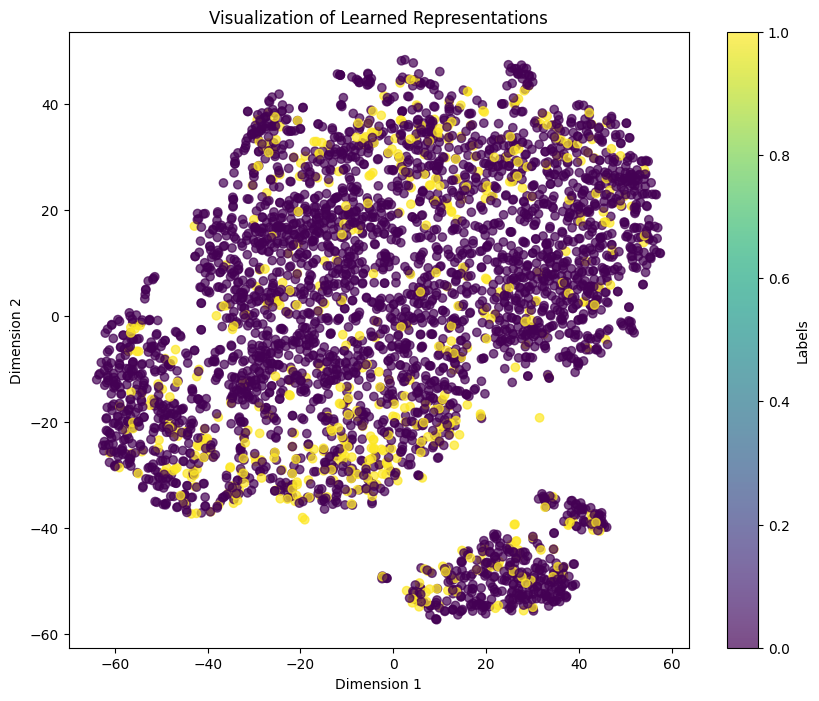

In [10]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# t-SNE for visualization
tsne = TSNE(n_components=2, random_state=42)
reduced_embeddings = tsne.fit_transform(train_embeddings_array)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1], c=y_train, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='Labels')
plt.title('Visualization of Learned Representations')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.show()

#### Q4.3 Using time-series foundation models

In [11]:
drop_cols = ["time", "ICUType"]
X_set_a = X_set_a.drop(columns=drop_cols)
X_set_b = X_set_b.drop(columns=drop_cols)
X_set_c = X_set_c.drop(columns=drop_cols)

In [12]:
from chronos import ChronosPipeline
import torch
import pickle

pipeline = ChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="cuda",
    torch_dtype=torch.float32,
)

def compute_patient_embeddings(data, pipeline):
    patient_embeddings = []
    unaggr_embeddings = []
    
    for _, patient_data in tqdm(data.groupby('recordid')):  # Group by patient ID
        channel_embeddings = []
        
        for channel in patient_data.columns[1:]:  # Exclude 'recordid' column
            series = patient_data[channel].values  # Drop NaN values for the channel
            if len(series) == 0:  # Skip if the channel has no data
                continue
    
            embedding, _ = pipeline.embed(torch.tensor(series.tolist(), dtype=torch.float32))
            channel_embeddings.append(embedding)

        if channel_embeddings:
            # Compute mean for each channel embedding across sequence length since each sequence has different lengths (dim=1)
            mean_embeddings = [torch.nanmean(emb, dim=1) for emb in channel_embeddings]  # Each becomes [1, 512]

            # Compute final patient embedding by taking mean across all channels
            aggregated_embedding = torch.nanmean(torch.stack(mean_embeddings), dim=0)  # Shape: [1, 512]
            patient_embeddings.append(aggregated_embedding)
            unaggr_embeddings.append(mean_embeddings)

    return np.array(patient_embeddings).squeeze(), np.array(unaggr_embeddings).squeeze()

# # Only need to compute once
# train_embeddings, non_agg_train_embeddings = compute_patient_embeddings(X_set_a, pipeline)
# with open("train_embeddings.pkl", "wb") as f:
#     pickle.dump(train_embeddings, f)
# with open("non_agg_train_embeddings.pkl", "wb") as f:
#     pickle.dump(non_agg_train_embeddings, f)
    
# valid_embeddings, non_agg_valid_embeddings = compute_patient_embeddings(X_set_b, pipeline)
# with open("valid_embeddings.pkl", "wb") as f:
#     pickle.dump(valid_embeddings, f)
# with open("non_agg_valid_embeddings.pkl", "wb") as f:
#     pickle.dump(non_agg_valid_embeddings, f)

# test_embeddings, non_agg_test_embeddings = compute_patient_embeddings(X_set_c, pipeline)
# with open("test_embeddings.pkl", "wb") as f:
#     pickle.dump(test_embeddings, f)
# with open("non_agg_test_embeddings.pkl", "wb") as f:
#     pickle.dump(non_agg_test_embeddings, f)

# Load the saved embeddings from files
with open("train_embeddings.pkl", "rb") as f:
    train_embeddings = pickle.load(f)
with open("valid_embeddings.pkl", "rb") as f:
    valid_embeddings = pickle.load(f)
with open("test_embeddings.pkl", "rb") as f:
    test_embeddings = pickle.load(f)

print("Train embeddings shape:", train_embeddings.shape)
print("Valid embeddings shape:", valid_embeddings.shape)
print("Test embeddings shape:", test_embeddings.shape)

clf = LogisticRegression(max_iter=1000)
clf.fit(train_embeddings, y_train)

test_predictions = clf.predict_proba(test_embeddings)[:, 1]

auroc = roc_auc_score(y_test, test_predictions)
auprc = average_precision_score(y_test, test_predictions)

print(f"AUROC: {auroc}")
print(f"AUPRC: {auprc}")

Train embeddings shape: (4000, 512)
Valid embeddings shape: (4000, 512)
Test embeddings shape: (4000, 512)
AUROC: 0.6345058878001777
AUPRC: 0.23619165208816562


In [13]:
with open("non_agg_train_embeddings.pkl", "rb") as f:
    non_agg_train_embeddings = pickle.load(f)
with open("non_agg_valid_embeddings.pkl", "rb") as f:
    non_agg_valid_embeddings = pickle.load(f)
with open("non_agg_test_embeddings.pkl", "rb") as f:
    non_agg_test_embeddings = pickle.load(f)

print("Non aggregated train embeddings shape:", non_agg_train_embeddings.shape)
print("Non aggregated validation embeddings shape:", non_agg_valid_embeddings.shape)
print("Non aggregated test embeddings shape:", non_agg_test_embeddings.shape)

Non aggregated train embeddings shape: (4000, 40, 512)
Non aggregated validation embeddings shape: (4000, 40, 512)
Non aggregated test embeddings shape: (4000, 40, 512)


In [14]:
import torch
from sklearn.metrics import roc_auc_score, average_precision_score

import torch.nn as nn
import torch.optim as optim

# Define the neural network architecture
class ChannelAggregator(nn.Module):
    def __init__(self, embedding_dim):
        super(ChannelAggregator, self).__init__()
        self.fc1 = nn.Linear(embedding_dim, embedding_dim)
        self.fc2 = nn.Linear(embedding_dim, embedding_dim)
        self.relu = nn.ReLU()
        self.attention = nn.Linear(embedding_dim, 1)  # Attention mechanism
        self.output_layer = nn.Linear(embedding_dim, 1)

    def forward(self, x):
        # x shape: (batch_size, num_channels, embedding_dim)
        x = self.fc1(x)  # Apply first fully connected layer to each channel
        x = self.relu(x)
        x = self.fc2(x)  # Apply second fully connected layer
        x = self.relu(x)
        
        # Attention mechanism
        attention_weights = torch.softmax(self.attention(x), dim=1)  # Compute attention weights
        x = torch.sum(attention_weights * x, dim=1)  # Weighted sum across channels
        
        x = self.output_layer(x)  # Final output layer
        return torch.sigmoid(x).squeeze()

# Prepare the data
def prepare_data(non_agg_embeddings, labels):
    data = [torch.stack([torch.tensor(channel) for channel in patient]) for patient in non_agg_embeddings]
    labels = torch.tensor(labels, dtype=torch.float32)
    return data, labels

train_data, train_labels = prepare_data(non_agg_train_embeddings, y_train)
valid_data, valid_labels = prepare_data(non_agg_valid_embeddings, y_valid)
test_data, test_labels = prepare_data(non_agg_test_embeddings, y_test)

# Create data loaders
train_loader = torch.utils.data.DataLoader(list(zip(train_data, train_labels)), batch_size=32, shuffle=True)
valid_loader = torch.utils.data.DataLoader(list(zip(valid_data, valid_labels)), batch_size=32, shuffle=False)
test_loader = torch.utils.data.DataLoader(list(zip(test_data, test_labels)), batch_size=32, shuffle=False)

# Initialize the model, loss function, and optimizer with regularization
embedding_dim = train_data[0].shape[-1]
model = ChannelAggregator(embedding_dim).to("cuda")
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# Early stopping parameters
patience = 5
best_val_auroc = 0
early_stop_counter = 0

# Train the model with early stopping
num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for batch_data, batch_labels in train_loader:
        batch_data, batch_labels = batch_data.to("cuda"), batch_labels.to("cuda")
        optimizer.zero_grad()
        outputs = model(batch_data)
        loss = criterion(outputs, batch_labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    # Calculate validation scores
    model.eval()
    val_preds = []
    val_labels = []
    with torch.no_grad():
        for batch_data, batch_labels in valid_loader:
            batch_data, batch_labels = batch_data.to("cuda"), batch_labels.to("cuda")
            outputs = model(batch_data)
            val_preds.extend(outputs.cpu().numpy())
            val_labels.extend(batch_labels.cpu().numpy())
    
    val_auroc = roc_auc_score(val_labels, val_preds)
    val_auprc = average_precision_score(val_labels, val_preds)
    
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss/len(train_loader):.4f}, "
          f"Validation AUROC: {val_auroc:.4f}, Validation AUPRC: {val_auprc:.4f}")
    
    # Early stopping logic
    if val_auroc > best_val_auroc:
        best_val_auroc = val_auroc
        early_stop_counter = 0
        best_model_state = model.state_dict()  # Save the best model
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print("Early stopping triggered.")
            break

# Load the best model for evaluation
model.load_state_dict(best_model_state)

# Evaluate the model
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for batch_data, batch_labels in test_loader:
        batch_data, batch_labels = batch_data.to("cuda"), batch_labels.to("cuda")
        outputs = model(batch_data)
        all_preds.extend(outputs.cpu().numpy())
        all_labels.extend(batch_labels.cpu().numpy())

# Calculate AUROC and AUPRC
auroc = roc_auc_score(all_labels, all_preds)
auprc = average_precision_score(all_labels, all_preds)

print(f"Test Set AUROC: {auroc:.4f}")
print(f"Test Set AUPRC: {auprc:.4f}")

Epoch 1/50, Loss: 0.4207, Validation AUROC: 0.6539, Validation AUPRC: 0.2561
Epoch 2/50, Loss: 0.3983, Validation AUROC: 0.6557, Validation AUPRC: 0.2531
Epoch 3/50, Loss: 0.3931, Validation AUROC: 0.6695, Validation AUPRC: 0.2602
Epoch 4/50, Loss: 0.3893, Validation AUROC: 0.6695, Validation AUPRC: 0.2599
Epoch 5/50, Loss: 0.3876, Validation AUROC: 0.6661, Validation AUPRC: 0.2584
Epoch 6/50, Loss: 0.3863, Validation AUROC: 0.6682, Validation AUPRC: 0.2621
Epoch 7/50, Loss: 0.3868, Validation AUROC: 0.6717, Validation AUPRC: 0.2677
Epoch 8/50, Loss: 0.3881, Validation AUROC: 0.6704, Validation AUPRC: 0.2647
Epoch 9/50, Loss: 0.3864, Validation AUROC: 0.6697, Validation AUPRC: 0.2662
Epoch 10/50, Loss: 0.3849, Validation AUROC: 0.6743, Validation AUPRC: 0.2727
Epoch 11/50, Loss: 0.3834, Validation AUROC: 0.6756, Validation AUPRC: 0.2736
Epoch 12/50, Loss: 0.3840, Validation AUROC: 0.6735, Validation AUPRC: 0.2749
Epoch 13/50, Loss: 0.3804, Validation AUROC: 0.6884, Validation AUPRC: 0.